# User Experience Analysis

### Installing Required Libraries

In [1]:
pip install pyodbc sqlalchemy

Defaulting to user installation because normal site-packages is not writeable
Note: you may need to restart the kernel to use updated packages.


### Importing Libraries

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from scipy.stats import zscore
from sqlalchemy import create_engine

Loads popular Python libraries for data analysis, visualization, machine learning, and database connection.

### Function: load_and_clean_data()

In [3]:
def load_and_clean_experience_data():
    try:
        df = pd.read_csv(r'dataset/telcom_data (2).xlsx - Sheet1.csv')
        print("Data loaded successfully. Initial shape:", df.shape)
        
        # Clean experience-related columns
        exp_cols = ['Avg RTT DL (ms)', 'Avg RTT UL (ms)', 'Avg Bearer TP DL (kbps)', 'TCP DL Retrans. Vol (Bytes)']
        for col in exp_cols:
            df[col] = pd.to_numeric(df[col], errors='coerce').fillna(df[col].median())
        
        # Remove outliers
        z_scores = np.abs(zscore(df[exp_cols]))
        threshold = 3
        df = df[(z_scores < threshold).all(axis=1)]
        print("Data after outlier removal:", df.shape)
        
        return df
    except Exception as e:
        print(f"Error in data loading/cleaning: {str(e)}")
        return None

### Insights

* Loads the dataset from a CSV file and prints its initial size.
* Cleans numerical columns & Converts them to numbers.
* Fixes invalid values by replacing them with the median.
* Removes outliers using the Z-score method.
* If anything goes wrong, it prints the error and returns None.

### Function: analyze_experience()

In [4]:
def analyze_experience(df):
    try:
        # Aggregate metrics per user
        experience_metrics = df.groupby('MSISDN/Number').agg(
            avg_rtt=('Avg RTT DL (ms)', 'mean'),
            avg_throughput=('Avg Bearer TP DL (kbps)', 'mean'),
            tcp_retrans=('TCP DL Retrans. Vol (Bytes)', 'mean')
        ).reset_index()

        # Normalize
        scaler = StandardScaler()
        experience_metrics[['norm_rtt', 'norm_throughput', 'norm_retrans']] = scaler.fit_transform(
            experience_metrics[['avg_rtt', 'avg_throughput', 'tcp_retrans']]
        )

        # Clustering
        kmeans = KMeans(n_clusters=3, random_state=42)
        experience_metrics['cluster'] = kmeans.fit_predict(experience_metrics[['norm_rtt', 'norm_throughput', 'norm_retrans']])

        # Visualization
        plt.figure(figsize=(10, 6))
        sns.scatterplot(data=experience_metrics, x='avg_throughput', y='avg_rtt', hue='cluster', palette='coolwarm')
        plt.title('User Experience Clusters')
        plt.xlabel('Throughput (kbps)')
        plt.ylabel('RTT (ms)')
        plt.show()

        return experience_metrics  # ✅ Correctly indented
    except Exception as e:
        print(f"Error in experience analysis: {str(e)}")
        return None

### Function: save_to_database()

In [5]:
def save_to_database(df, table_name):
    try:
        server = 'ANIKET\\SQLEXPRESS'
        database = 'telecom_analytics'
        connection_url = (
            f"mssql+pyodbc://{server}/{database}"
            "?driver=ODBC+Driver+17+for+SQL+Server"
            "&trusted_connection=yes"
        )
        engine = create_engine(connection_url)
        
        df.columns = df.columns.str.replace('[^a-zA-Z0-9_]', '_', regex=True)
        df.to_sql(table_name, engine, if_exists='replace', index=False)
        print(f"Data saved to SQL table: {table_name}")
        engine.dispose()
    except Exception as e:
        print(f"Error saving to database: {str(e)}")

### Main Execution

Data loaded successfully. Initial shape: (150001, 55)
Data after outlier removal: (145027, 55)


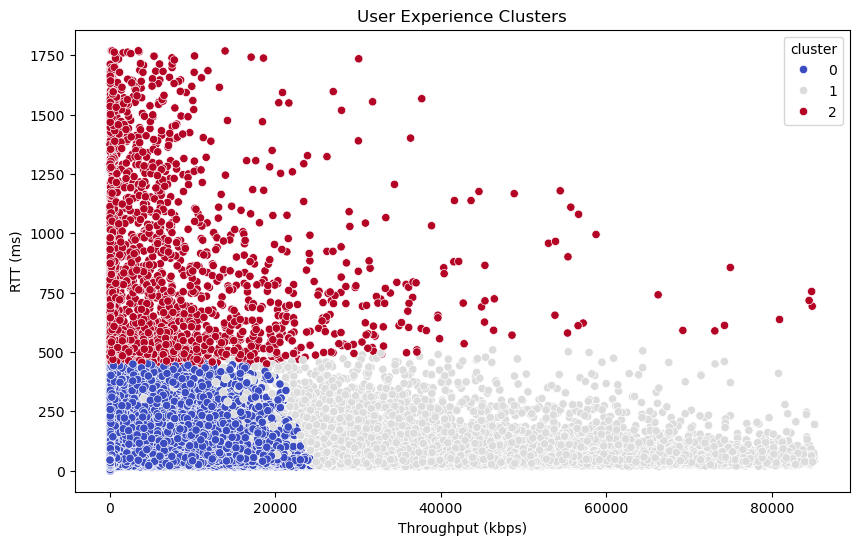

Data saved to SQL table: user_experience_metrics
Users with High RTT (>200ms):
        MSISDN_Number  avg_rtt
20       3.360103e+10    489.0
47       3.360108e+10    355.0
49       3.360108e+10    212.0
88       3.360118e+10    288.0
89       3.360118e+10    739.0
...               ...      ...
104379   3.378923e+10    779.0
104397   3.378941e+10    497.0
104417   3.378951e+10    223.0
104450   3.378962e+10    714.5
104454   3.378965e+10    289.0

[6081 rows x 2 columns]


In [6]:
# Main execution
if __name__ == "__main__":
    df = load_and_clean_experience_data()
    if df is not None:
        experience_metrics = analyze_experience(df)
        if experience_metrics is not None:
            save_to_database(experience_metrics, 'user_experience_metrics')
            # Save to CSV for later use
            experience_metrics.to_csv(r'dataset\experience_metrics.csv', index=False)
            
            print("Users with High RTT (>200ms):")
            print(experience_metrics[experience_metrics['avg_rtt'] > 200][['MSISDN_Number', 'avg_rtt']])